# Result Comparison 

## 1. Import Libraries and Load Data

In [1]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt



import sys
from pathlib import Path

project_dir = Path("..").resolve()

if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

from src.dataset import TreeDataset
from src.tree_isolation import treeIso


# 2. Testing tree_isolation.py file

Number of groups: 17
Size of largest group: 38236
main_tree_mask
True


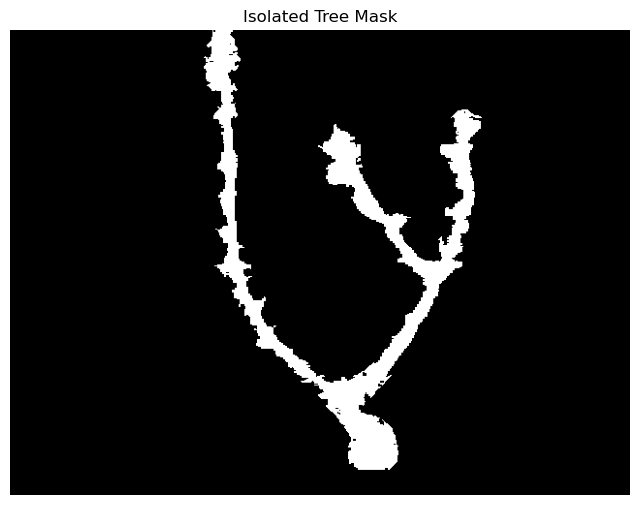

In [16]:
import matplotlib.pyplot as plt

isolatedTree = treeIso("R01N03")

plt.figure(figsize=(8, 8))
plt.imshow(isolatedTree, cmap="gray")
plt.title("Isolated Tree Mask")
plt.axis("off")
plt.show()

# 3. Create comparison between single tree reconstruction and Gt

Summer GT: (256, 256)
Isolated Tree: (480, 640)


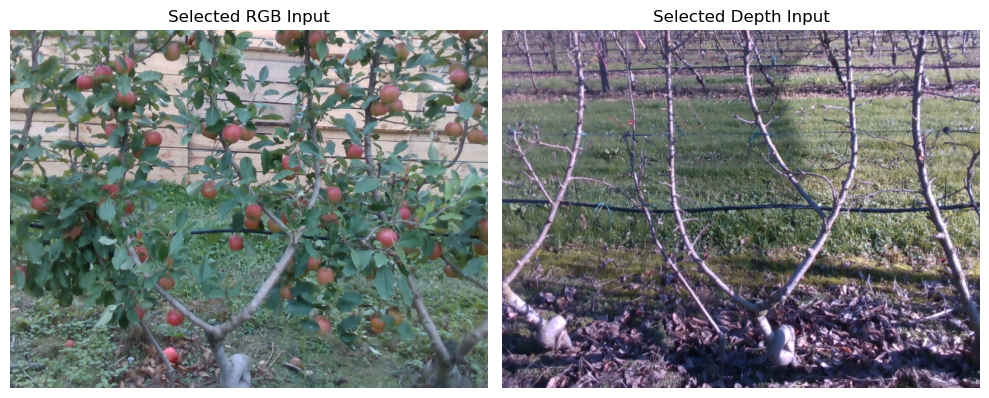

In [21]:
data_dir = project_dir / "data/raw/Dataset (With Summer GT)"
dataset = TreeDataset(data_dir)
tree = dataset.get_tree("R01N03")

print("Summer GT:", tree.summer_gt.shape)
print("Isolated Tree:", isolatedTree.shape)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(tree.summer_rgb)
axes[0].set_title("Selected RGB Input")

axes[1].imshow(tree.winter_rgb, cmap="viridis")
axes[1].set_title("Selected Depth Input")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

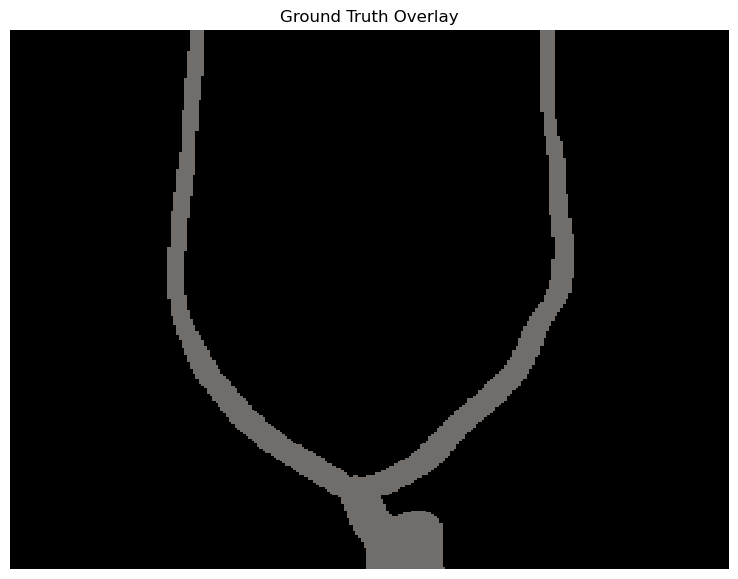

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load tree
data_dir = project_dir / "data/raw/Dataset (With Summer GT)"
dataset = TreeDataset(data_dir)
tree = dataset.get_tree("R01N03")

# Your isolated tree mask
prediction = np.asarray(tree.summer_rgb)

# Ground truth
gt = np.asarray(tree.summer_gt)

# Convert to binary masks
if prediction.ndim == 3:
    prediction = np.any(prediction > 0, axis=2)
else:
    prediction = prediction > 0

if gt.ndim == 3:
    gt = np.any(gt > 0, axis=2)
else:
    gt = gt > 0

# Resize GT to match prediction
height, width = prediction.shape

gt_resized = np.array(
    Image.fromarray(gt.astype(np.uint8)).resize(
        (width, height),
        Image.Resampling.NEAREST
    )
).astype(bool)

# Plot overlay
plt.figure(figsize=(10, 7))

plt.imshow(prediction, cmap="gray")
plt.imshow(
    np.ma.masked_where(~gt_resized, gt_resized),
    cmap="Reds",
    alpha=0.45,
    interpolation="nearest"
)

plt.title("Ground Truth Overlay")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display

height, width = isolatedTree.shape

# Create figure once
fig, ax = plt.subplots(figsize=(10, 7))

ax.imshow(isolatedTree, cmap="gray")

# Initial GT overlay
overlay = ax.imshow(
    np.ma.masked_where(~tree.summer_gt, tree.summer_gt),
    cmap="Reds",
    alpha=0.5,
    interpolation="nearest"
)

ax.set_xlim(-0.5, width - 0.5)
ax.set_ylim(height - 0.5, -0.5)
ax.set_title("Ground Truth Alignment")

plt.close(fig)


def show_overlay(x_offset, y_offset, scale, opacity):

    new_width = max(1, int(width * scale))
    new_height = max(1, int(height * scale))

    scaled_gt = np.array(
        Image.fromarray(tree.summer_gt.astype(np.uint8)).resize(
            (new_width, new_height),
            Image.Resampling.NEAREST
        )
    ).astype(bool)

    x_start = (width - new_width) // 2 + x_offset
    y_start = (height - new_height) // 2 + y_offset

    # Update existing overlay
    overlay.set_data(np.ma.masked_where(~scaled_gt, scaled_gt))

    overlay.set_extent([
        x_start - 0.5,
        x_start + new_width - 0.5,
        y_start + new_height - 0.5,
        y_start - 0.5
    ])

    overlay.set_alpha(opacity)

    display(fig)


# Sliders
x_slider = widgets.IntSlider(
    value=0, min=-200, max=200,
    description="X Offset",
    continuous_update=False
)

y_slider = widgets.IntSlider(
    value=0, min=-200, max=200,
    description="Y Offset",
    continuous_update=False
)

scale_slider = widgets.FloatSlider(
    value=1.0, min=0.5, max=1.5,
    step=0.01,
    description="Scale",
    continuous_update=False
)

opacity_slider = widgets.FloatSlider(
    value=0.5, min=0, max=1,
    step=0.05,
    description="Opacity",
    continuous_update=False
)

controls = {
    "x_offset": x_slider,
    "y_offset": y_slider,
    "scale": scale_slider,
    "opacity": opacity_slider
}

output = widgets.interactive_output(show_overlay, controls)

display(
    widgets.VBox([
        x_slider,
        y_slider,
        scale_slider,
        opacity_slider,
        output
    ])
)

# 4. Aligning GT with winter image

After investigation it was found that the winter rgb images and the summer gt images were taken from different spot

Rather then restating i am going to try ad align the v junctions in both the summer gt and the winter rbg images. from the previous investigations is was found that approximately the summer image was 75% the size of the winter images so that will be scaled first and then the v junctions will be aligned. 

### Code to find the v junction for a tree

In [36]:
import numpy as np
from PIL import Image

def find_v_junction(mask, min_gap=20, min_height=40, min_width=3):

    mask = np.asarray(mask)

    if mask.ndim == 3:
        mask = np.any(mask > 0, axis=2)
    else:
        mask = mask > 0

    height, width = mask.shape

    rows, cols = np.where(mask)

    if len(rows) == 0:
        return None

    top = rows.min()
    bottom = rows.max()

    # Search for the V in the lower 85% of the tree
    search_top = int(top + 0.15 * (bottom - top))

    # Store the centre of the gap at each row
    gaps = []

    for y in range(search_top, bottom + 1):

        row = mask[y]

        # Find continuous white sections
        changes = np.diff(
            np.concatenate(([False], row, [False])).astype(int)
        )

        starts = np.where(changes == 1)[0]
        ends = np.where(changes == -1)[0]

        widths = ends - starts

        # Ignore very small sections
        valid = widths >= min_width

        starts = starts[valid]
        ends = ends[valid]

        if len(starts) < 2:
            gaps.append(None)
            continue

        # Find the two largest sections
        indices = np.argsort(ends - starts)[-2:]

        sections = sorted(
            [(starts[i], ends[i]) for i in indices]
        )

        left, right = sections

        gap_width = right[0] - left[1]

        if gap_width >= min_gap:

            gap_centre = (left[1] + right[0]) / 2

            gaps.append((gap_centre, y))

        else:
            gaps.append(None)

    # Find continuous runs of rows containing a gap
    runs = []
    current_run = []

    for point in gaps:

        if point is not None:
            current_run.append(point)

        else:
            if len(current_run) >= min_height:
                runs.append(current_run)

            current_run = []

    if len(current_run) >= min_height:
        runs.append(current_run)

    if not runs:
        return None

    # Choose the run extending furthest down the tree
    best_run = max(runs, key=lambda run: run[-1][1])

    # Bottom of the V-shaped gap
    x, y = best_run[-1]

    return int(x), int(y)

In [34]:
tree = dataset.get_tree("R01N03")

prediction = np.asarray(isolatedTree)
gt = np.asarray(tree.summer_gt)

# Convert GT to binary
if gt.ndim == 3:
    gt = np.any(gt > 0, axis=2)
else:
    gt = gt > 0

height, width = prediction.shape[:2]

scale = 0.75

new_width = int(width * scale)
new_height = int(height * scale)

gt_scaled = np.array(
    Image.fromarray(gt.astype(np.uint8)).resize(
        (new_width, new_height),
        Image.Resampling.NEAREST
    )
).astype(bool)

In [37]:
predicted_junction = find_v_junction(
    prediction,
    min_gap=20,
    min_height=40
)

gt_junction = find_v_junction(
    gt_scaled,
    min_gap=15,
    min_height=25
)

print("Predicted junction:", predicted_junction)
print("GT junction:", gt_junction)

Predicted junction: (337, 361)
GT junction: (234, 296)


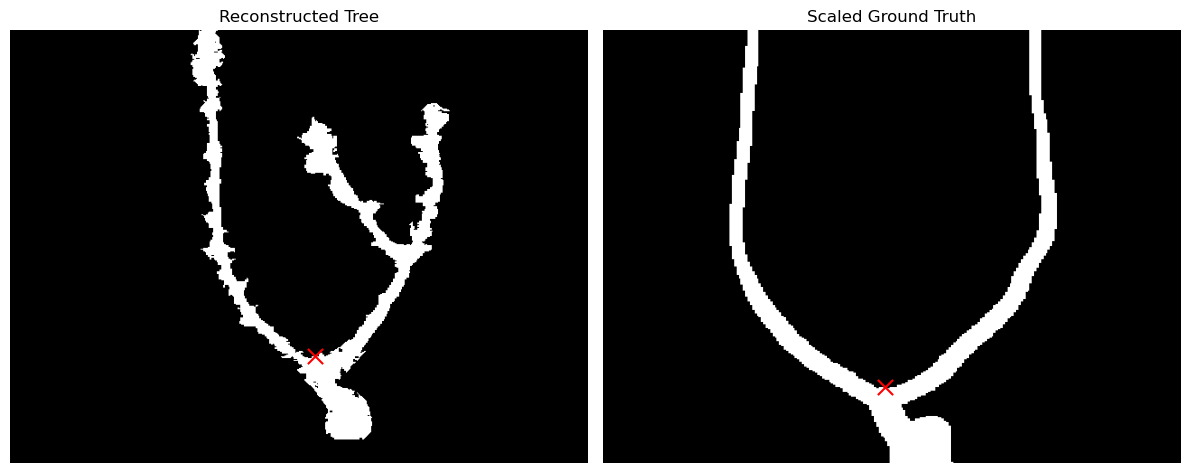

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

images = [
    (prediction, predicted_junction, "Reconstructed Tree"),
    (gt_scaled, gt_junction, "Scaled Ground Truth")
]

for ax, (img, point, title) in zip(axes, images):

    ax.imshow(img, cmap="gray")

    if point is not None:
        ax.scatter(
            point[0],
            point[1],
            color="red",
            marker="x",
            s=120
        )

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Align Images

In [40]:
import numpy as np

# Convert prediction to binary
prediction = np.asarray(prediction).astype(bool)
gt_scaled = np.asarray(gt_scaled).astype(bool)

height, width = prediction.shape

# Calculate required translation
x_offset = predicted_junction[0] - gt_junction[0]
y_offset = predicted_junction[1] - gt_junction[1]

print("X offset:", x_offset)
print("Y offset:", y_offset)

# Create empty matrix with same dimensions as prediction
gt_aligned = np.zeros((height, width), dtype=bool)

# Dimensions of scaled GT
gt_height, gt_width = gt_scaled.shape

# Calculate destination boundaries
x1 = max(0, x_offset)
y1 = max(0, y_offset)

x2 = min(width, x_offset + gt_width)
y2 = min(height, y_offset + gt_height)

# Calculate corresponding source boundaries
src_x1 = x1 - x_offset
src_y1 = y1 - y_offset

src_x2 = src_x1 + (x2 - x1)
src_y2 = src_y1 + (y2 - y1)

# Copy GT into aligned matrix
if x2 > x1 and y2 > y1:
    gt_aligned[y1:y2, x1:x2] = gt_scaled[
        src_y1:src_y2,
        src_x1:src_x2
    ]

print("Prediction shape:", prediction.shape)
print("Aligned GT shape:", gt_aligned.shape)

X offset: 103
Y offset: 65
Prediction shape: (480, 640)
Aligned GT shape: (480, 640)


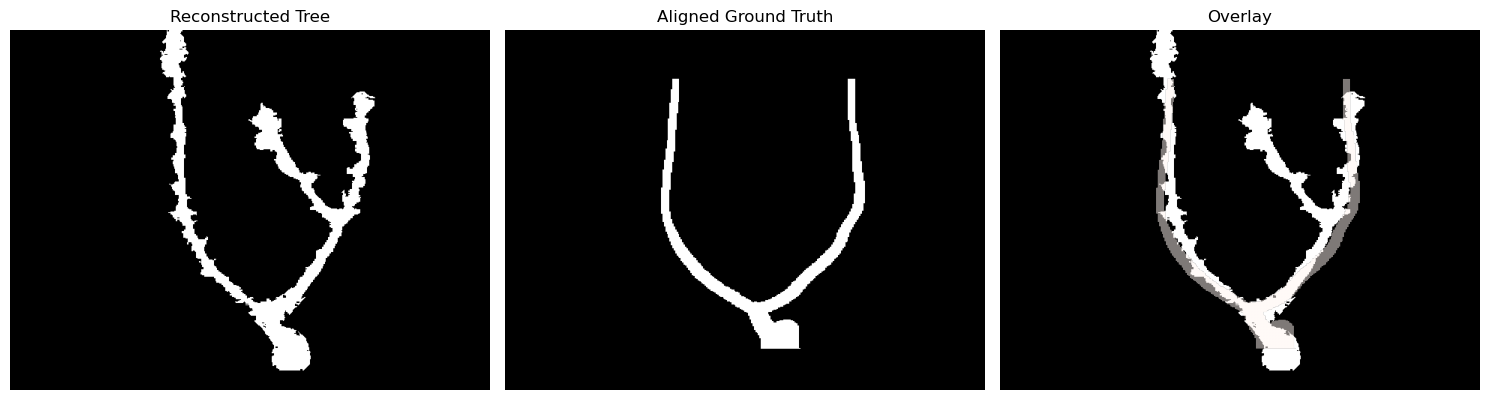

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(prediction, cmap="gray")
axes[0].set_title("Reconstructed Tree")

axes[1].imshow(gt_aligned, cmap="gray")
axes[1].set_title("Aligned Ground Truth")

# Overlay
axes[2].imshow(prediction, cmap="gray")
axes[2].imshow(
    np.ma.masked_where(~gt_aligned, gt_aligned),
    cmap="Reds",
    alpha=0.5
)
axes[2].set_title("Overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 5. comparing aligned images

### Error Types

In [43]:
TP = prediction & gt_aligned
FP = prediction & ~gt_aligned
FN = ~prediction & gt_aligned
TN = ~prediction & ~gt_aligned

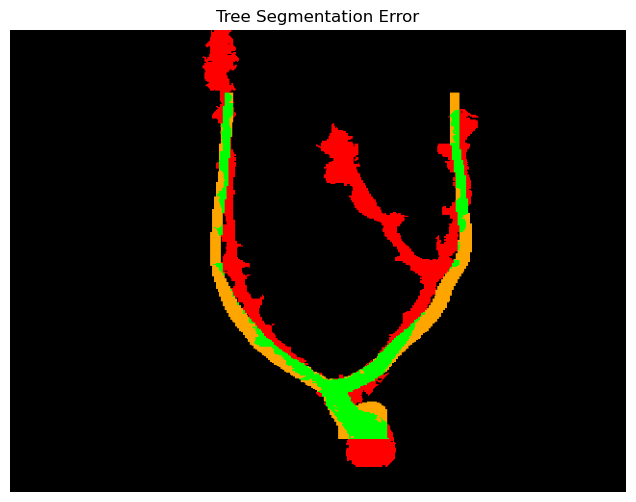

In [44]:
# Create RGB image
error_image = np.zeros((height, width, 3), dtype=np.uint8)

# True positive = Green
error_image[TP] = [0, 255, 0]

# False positive = Red
error_image[FP] = [255, 0, 0]

# False negative = Orange
error_image[FN] = [255, 165, 0]

plt.figure(figsize=(8, 6))
plt.imshow(error_image)
plt.title("Tree Segmentation Error")
plt.axis("off")
plt.show()

In [45]:
tp = np.sum(TP)
fp = np.sum(FP)
fn = np.sum(FN)
tn = np.sum(TN)

iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else np.nan

dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else np.nan

precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan

print(f"IoU:       {iou:.4f}")
print(f"Dice:      {dice:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

IoU:       0.2555
Dice:      0.4070
Precision: 0.3286
Recall:    0.5346
